## 🔗 Vínculos del Proyecto
*   **Repositorio GitHub:** [telecom-operator-efficiency](https://github.com/gersonv-bda/telecom-operator-efficiency)
*   **Presentación Ejecutiva (PDF):** [Presentacion_CallMeMaybe](https://drive.google.com/drive/folders/1RsYGeRjkLSar4xZ3WgY7sCSpKSIP11Pk?usp=sharing)
*   **Dashboard Interactivo (Tableau):** [El Punto Crítico: Diagnóstico de Productividad en Equipos Mixtos](https://public.tableau.com/views/ElPuntoCrticoDiagnsticodeProductividadenEquiposMixtos/AuditoradeDesempeoOperativo?:language=es-ES&publish=yes&:sid=&:display_count=n&:origin=viz_share_link)

# Proyecto Final: Identificación de Operadores Ineficaces - CallMeMaybe

## 1. Introducción y Objetivo
El presente proyecto tiene como finalidad desarrollar un modelo de diagnóstico para la empresa de telefonía virtual **CallMeMaybe**. El objetivo central es identificar operadores que presenten bajos niveles de rendimiento basándonos en tres métricas críticas:

*   **Gestión de llamadas entrantes:** Alta tasa de llamadas perdidas.
*   **Eficiencia de respuesta:** Tiempos de espera excesivos, factor crítico para la conexión emocional con la marca (Magids et al., 2015).
*   **Productividad saliente:** Bajo volumen de llamadas realizadas (para perfiles específicos).

## 2. Estrategia de Análisis y Segmentación
Para asegurar una evaluación justa y evitar sesgos metodológicos, este análisis no tratará a todos los operadores por igual. Basándonos en la literatura de gestión de operaciones (Gans, Koole, & Mandelbaum, 2003), segmentaremos a los operadores según su perfil funcional (*Inbound* vs. *Outbound*). Esto nos permitirá aplicar umbrales de ineficacia diferenciados y alineados a la realidad operativa de cada rol.

## 3. Hoja de Ruta (Roadmap)
*   **Paso 0: Preparación:** Configuración del entorno, carga de librerías y datasets.
*   **Paso 1: Exploración y Limpieza (EDA):** Identificación de duplicados, valores ausentes y corrección de tipos de datos.
*   **Paso 2: Ingeniería de Características:** Creación de métricas de rendimiento y segmentación de perfiles.
*   **Paso 3: Identificación de Operadores Ineficaces:** Aplicación de filtros y lógica de negocio para determinar el grupo objetivo.
*   **Paso 4: Pruebas de Hipótesis:** Validación estadística de las diferencias de rendimiento detectadas.
*   **Paso 5: Conclusiones y Recomendaciones:** Entrega de hallazgos estratégicos.

## Paso 0: Configuración del Entorno y Carga de Datos

En esta sección prepararemos nuestro ecosistema de trabajo. Importaremos las librerías esenciales para el procesamiento de datos (`pandas`, `numpy`), visualización (`matplotlib`, `seaborn`) y análisis estadístico (`scipy.stats`).

Además, estableceremos las configuraciones de visualización para asegurar que todas las gráficas mantengan una estética profesional y consistente a lo largo del proyecto.

In [1]:
# ==============================================================================
# PASO 0.1: Importación de librerías y carga de datasets
# ==============================================================================

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as st

# Configuración de visualización para que los gráficos sean consistentes
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]

# Carga de archivos
# Definimos los nombres de los archivos
file_telecom = 'telecom_dataset_us.csv'
file_clients = 'telecom_clients_us.csv'

# Lista de bases de rutas posibles (intentando abarcar lo más común)
base_paths = [
    '/datasets/',                # Plataforma TripleTen
    'data/',                     # Raíz del proyecto
    '../data/',                  # Carpeta /notebooks
    './'                         # Misma carpeta
]

telecom_data = None
clients_data = None

for base in base_paths:
    path_telecom = os.path.join(base, file_telecom)
    path_clients = os.path.join(base, file_clients)
    
    # Verificamos que AMBOS archivos existan en la misma ubicación
    if os.path.exists(path_telecom) and os.path.exists(path_clients):
        try:
            telecom_data = pd.read_csv(path_telecom)
            clients_data = pd.read_csv(path_clients)
            print(f"Datasets cargados exitosamente desde: {base}")
            break # Salimos del bucle solo si ambos cargaron
        except Exception as e:
            print(f"Error al leer archivos en {base}: {e}")

# Verificación final de seguridad
if telecom_data is None or clients_data is None:
    raise FileNotFoundError(
        f"Error Crítico: No se pudo encontrar la pareja de archivos ({file_telecom} y {file_clients}) "
        "en ninguna de las rutas especificadas. Verifique la estructura de carpetas."
    )

# Primera vista de los datos
display(telecom_data.head())
display(clients_data.head())

Datasets cargados exitosamente desde: ../data/


,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration
0,166377,2019-08-04 00:00:00+03:00,in,False,NaN,True,2,0,4
1,166377,2019-08-05 00:00:00+03:00,out,True,880022.0,True,3,0,5
2,166377,2019-08-05 00:00:00+03:00,out,True,880020.0,True,1,0,1
3,166377,2019-08-05 00:00:00+03:00,out,True,880020.0,False,1,10,18
4,166377,2019-08-05 00:00:00+03:00,out,False,880022.0,True,3,0,25


,user_id,tariff_plan,date_start
0,166713,A,2019-08-15
1,166901,A,2019-08-23
2,168527,A,2019-10-29
3,167097,A,2019-09-01
4,168193,A,2019-10-16


In [2]:
# ==============================================================================
# PASO 0.2: Ecosistema de procesamiento, diagnóstico y utilidades
# ==============================================================================

# Sencilla función que aborda los aspectos mas generales de la normalización (snake_case)
# Podría requerir ajustes o ampliación de funciones según proceda
def normalize_columns(df):
    """Normaliza encabezados: minúsculas, sin espacios y caracteres especiales."""
    df.columns = (df.columns
                  .str.strip()
                  .str.lower()
                  .str.replace(' ', '_')
                  .str.replace(r'[^\w\s]', '', regex=True))
    return df

def exploratory_diagnostic(df, name="DataFrame"):
    """Ejecuta un diagnóstico integral de la salud del dataset incluyendo duplicados y nulos."""
    print(f"\n{'='*70}")
    print(f" DIAGNÓSTICO INTEGRAL: {name}")
    print(f"{'='*70}")
    print(f"Dimensiones: {df.shape[0]} filas | {df.shape[1]} columnas")
    
    # Verificación de duplicados
    dup_count = df.duplicated().sum()
    print(f"\n[ALERTA] Duplicados: {dup_count} ({ (dup_count/len(df)*100):.2f}%)")
    
    # Análisis de valores ausentes
    print("\n[INFO] Valores ausentes por columna:")
    nulls = df.isna().sum()
    print(nulls[nulls > 0] if nulls.sum() > 0 else "No se detectaron valores nulos.")
    
    print("\n[INFO] Estructura y Tipos:")
    df.info()
    
    print("\n[INFO] Estadísticas Descriptivas (Numéricas):")
    display(df.describe(include='all').T)

def classify_operator_role(outbound_share, high_threshold=0.7, low_threshold=0.3):
    """
    Clasifica el rol del operador basado en la proporción de llamadas salientes.
    Basado en Gans et al. (2003).
    """
    if outbound_share > high_threshold:
        return 'Outbound'
    elif outbound_share < low_threshold:
        return 'Inbound'
    return 'Mixed'

print("=" * 70)
print("✅ Funciones de apoyo cargadas y listas para el procesamiento.")
print("=" * 70)

✅ Funciones de apoyo cargadas y listas para el procesamiento.


## Paso 1: Exploración y Limpieza de Datos (EDA Inicial)

Antes de avanzar al análisis profundo, debemos garantizar la **"Higiene del Proyecto"**. En esta etapa realizaremos un escaneo crítico para detectar y resolver:

1.  **Tipos de datos incorrectos:** Transformación de columnas temporales a formato `datetime`.
2.  **Valores ausentes:** Evaluación del impacto de nulos, especialmente en la columna `operator_id`.
3.  **Duplicados:** Eliminación de registros redundantes para evitar sesgos en el cálculo de KPIs.

Utilizaremos nuestro diagnóstico integral para establecer la línea base de limpieza.

In [3]:
# ==============================================================================
# PASO 1.1: Ejecución de diagnóstico inicial de limpieza
# ==============================================================================

# Normalización preventiva
# En caso de recibir el DF sin snake_case, activamos lo siguiente.
# telecom_data = normalize_columns(telecom_data)
# clients_data = normalize_columns(clients_data)

# Diagnóstico integral
exploratory_diagnostic(telecom_data, "Telecom Behavior (Raw)")
exploratory_diagnostic(clients_data, "Clients Data (Raw)")


 DIAGNÓSTICO INTEGRAL: Telecom Behavior (Raw)
Dimensiones: 53902 filas | 9 columnas

[ALERTA] Duplicados: 4900 (9.09%)

[INFO] Valores ausentes por columna:
internal        117
operator_id    8172
dtype: int64

[INFO] Estructura y Tipos:
<class 'pandas.DataFrame'>
RangeIndex: 53902 entries, 0 to 53901
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   user_id              53902 non-null  int64  
 1   date                 53902 non-null  str    
 2   direction            53902 non-null  str    
 3   internal             53785 non-null  object 
 4   operator_id          45730 non-null  float64
 5   is_missed_call       53902 non-null  bool   
 6   calls_count          53902 non-null  int64  
 7   call_duration        53902 non-null  int64  
 8   total_call_duration  53902 non-null  int64  
dtypes: bool(1), float64(1), int64(4), object(1), str(2)
memory usage: 3.3+ MB

[INFO] Estadísticas Descriptivas (

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
user_id,53902.0,NaN,NaN,NaN,167295.344477,598.883775,166377.0,166782.0,167162.0,167819.0,168606.0
date,53902,119,2019-11-25 00:00:00+03:00,1220,NaN,NaN,NaN,NaN,NaN,NaN,NaN
direction,53902,2,out,31917,NaN,NaN,NaN,NaN,NaN,NaN,NaN
internal,53785,2,False,47621,NaN,NaN,NaN,NaN,NaN,NaN,NaN
operator_id,45730.0,NaN,NaN,NaN,916535.993002,21254.123136,879896.0,900788.0,913938.0,937708.0,973286.0
is_missed_call,53902,2,False,30334,NaN,NaN,NaN,NaN,NaN,NaN,NaN
calls_count,53902.0,NaN,NaN,NaN,16.451245,62.91717,1.0,1.0,4.0,12.0,4817.0
call_duration,53902.0,NaN,NaN,NaN,866.684427,3731.791202,0.0,0.0,38.0,572.0,144395.0
total_call_duration,53902.0,NaN,NaN,NaN,1157.133297,4403.468763,0.0,47.0,210.0,902.0,166155.0



 DIAGNÓSTICO INTEGRAL: Clients Data (Raw)
Dimensiones: 732 filas | 3 columnas

[ALERTA] Duplicados: 0 (0.00%)

[INFO] Valores ausentes por columna:
No se detectaron valores nulos.

[INFO] Estructura y Tipos:
<class 'pandas.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   user_id      732 non-null    int64
 1   tariff_plan  732 non-null    str  
 2   date_start   732 non-null    str  
dtypes: int64(1), str(2)
memory usage: 17.3 KB

[INFO] Estadísticas Descriptivas (Numéricas):


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
user_id,732.0,NaN,NaN,NaN,167431.927596,633.810383,166373.0,166900.75,167432.0,167973.0,168606.0
tariff_plan,732,3,C,395,NaN,NaN,NaN,NaN,NaN,NaN,NaN
date_start,732,73,2019-09-24,24,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 1.2. Hallazgos del Diagnóstico y Estrategia de Limpieza

Tras ejecutar el diagnóstico integral, hemos identificado los siguientes puntos que requieren intervención inmediata:

*   **Duplicados:** Se detectó un **9.09%** de registros duplicados. Procederemos a eliminarlos para evitar sesgos en el conteo de llamadas y asegurar la integridad estadística.
*   **Gestión de `operator_id` ausentes:** Representan el **15.1%** de la data. Realizaremos una validación cruzada con `is_missed_call`. 
    *   *Estrategia:* Si los nulos corresponden a llamadas perdidas no asignadas, se mantendrán para el análisis de flujo general, pero se excluirán estrictamente al calcular métricas individuales de rendimiento por operador.
*   **Consistencia de Tipos:** Transformaremos la columna `date` a formato `datetime` e `internal` a un tipo de dato booleano/lógico para optimizar el procesamiento.
*   **Criterio de Calidad:** Mantendremos la trazabilidad del número de filas antes y después de la limpieza para asegurar que la pérdida de información sea mínima y esté plenamente justificada.

In [4]:
# ==============================================================================
# PASO 1.2.1: Saneamiento de Duplicados y Tipos de Datos
# ==============================================================================

# 1. Eliminación de duplicados (Punto de partida)
rows_before = len(telecom_data)
telecom_data = telecom_data.drop_duplicates().reset_index(drop=True)
rows_after = len(telecom_data)

print("=" * 70)
print(f"{'LIMPIEZA DE DUPLICADOS - REPORTE':^70}")
print("=" * 70)
print(f"✅ Filas eliminadas (duplicados): {rows_before - rows_after}")
print(f"📊 Nuevo tamaño del dataset: {rows_after} registros")
print("=" * 70)

# 2. Conversión de fechas para análisis temporal
telecom_data['date'] = pd.to_datetime(telecom_data['date'])
clients_data['date_start'] = pd.to_datetime(clients_data['date_start'])

# 3. Verificación Post-Limpieza de Nulos
print("\n[RE-DIAGNÓSTICO] Valores nulos tras eliminar duplicados:")
nulls_post = telecom_data.isna().sum()
print(nulls_post[nulls_post > 0])

                   LIMPIEZA DE DUPLICADOS - REPORTE                   
✅ Filas eliminadas (duplicados): 4900
📊 Nuevo tamaño del dataset: 49002 registros

[RE-DIAGNÓSTICO] Valores nulos tras eliminar duplicados:
internal        110
operator_id    7456
dtype: int64


In [5]:
# ==============================================================================
# PASO 1.2.1.1: Busqueda de horas en las fechas para verificar si hay información adicional
# ==============================================================================

# Buscar horas
print(telecom_data['date'].head()) 
# Verifica si después de extraer la hora hay algo más que ceros
print(telecom_data['date'].dt.hour.unique())

print(clients_data['date_start'].head()) 
# Verifica si después de extraer la hora hay algo más que ceros
print(clients_data['date_start'].dt.hour.unique())

0   2019-08-04 00:00:00+03:00
1   2019-08-05 00:00:00+03:00
2   2019-08-05 00:00:00+03:00
3   2019-08-05 00:00:00+03:00
4   2019-08-05 00:00:00+03:00
Name: date, dtype: datetime64[us, UTC+03:00]
[0]
0   2019-08-15
1   2019-08-23
2   2019-10-29
3   2019-09-01
4   2019-10-16
Name: date_start, dtype: datetime64[us]
[0]


In [6]:
# ==============================================================================
# PASO 1.2.2: Tratamiento de Valores Ausentes e Imputación
# ==============================================================================

# 1. Tratamiento de 'internal'
# Validamos si los nulos persisten y aplicamos moda (Llamadas Externas por defecto)
if telecom_data['internal'].isna().any():
    mode_val = telecom_data['internal'].mode()[0]
    telecom_data['internal'] = telecom_data['internal'].fillna(mode_val)
    print("=" * 70)
    print(f"{'TRATAMIENTO DE VALORES AUSENTES':^70}")
    print("=" * 70)
    print(f"✅ Nulos en 'internal' imputados con la moda: {mode_val}")
    print("=" * 70)

telecom_data['internal'] = telecom_data['internal'].astype(bool)

# 2. Análisis Crítico de 'operator_id'
# Investigamos la relación entre operadores ausentes y llamadas perdidas
null_operators = telecom_data[telecom_data['operator_id'].isna()]
prop_missed = null_operators['is_missed_call'].mean()

print(f"\n[HALLAZGO] Proporción de llamadas perdidas sin operator_id: {prop_missed:.2%}\n")

telecom_data.info()

# 3. Decisión Estratégica:
# Mantener los nulos en el DF principal para métricas globales de la empresa,
# pero crearemos un DF filtrado para el análisis específico de operadores.
print("\n✅ Fase de limpieza y tratamiento de nulos completada.")

                   TRATAMIENTO DE VALORES AUSENTES                    
✅ Nulos en 'internal' imputados con la moda: False

[HALLAZGO] Proporción de llamadas perdidas sin operator_id: 98.48%

<class 'pandas.DataFrame'>
RangeIndex: 49002 entries, 0 to 49001
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype                    
---  ------               --------------  -----                    
 0   user_id              49002 non-null  int64                    
 1   date                 49002 non-null  datetime64[us, UTC+03:00]
 2   direction            49002 non-null  str                      
 3   internal             49002 non-null  bool                     
 4   operator_id          41546 non-null  float64                  
 5   is_missed_call       49002 non-null  bool                     
 6   calls_count          49002 non-null  int64                    
 7   call_duration        49002 non-null  int64                    
 8   total_call_duration  49002 

### 1.3. Segmentación para Evaluación de Desempeño

Tras el análisis de nulos, confirmamos que el **98.48%** de los registros sin `operator_id` corresponden a llamadas perdidas. Dado que el objetivo central del proyecto es calificar la eficacia de los operadores individuales, procederemos a crear un subset de datos excluyendo los registros sin identificación.

*   **Justificación Técnica:** No es posible atribuir ineficacia o productividad a un individuo específico sin su identificador único (`operator_id`). 
*   **Gestión de Datos:** Estos registros se conservarán en el DataFrame original únicamente para análisis de volumen general y KPIs a nivel cuenta de cliente (`user_id`), pero no formarán parte del cálculo de métricas de desempeño por operador.

## Paso 2: Ingeniería de Características y Segmentación de Perfiles

En esta etapa transformaremos los datos crudos en métricas accionables (KPIs) que nos permitan medir la eficacia. No basta con observar el volumen de llamadas; debemos normalizar el comportamiento para identificar patrones de ineficiencia técnica y operativa.

### 2.1. Definición de Métricas (KPIs)
Siguiendo las mejores prácticas de la industria (MetricNet, 2020), implementaremos los siguientes indicadores:

*   **Waiting Time (Tiempo de Espera):** Calculado como la diferencia entre la duración total y la duración efectiva de la llamada.
*   **Average Waiting Time:** Tiempo de espera promedio por cada llamada dentro de un registro para evitar sesgos por volumen de tráfico.
*   **Missed Call Rate:** Proporción de llamadas no atendidas en relación con el total de intentos recibidos.

### 2.2. Estrategia de Segmentación de Operadores
Para cumplir con el criterio de "Habilidad Estratégica", no evaluaremos a un operador de ventas (*Outbound*) con los mismos criterios que a uno de soporte (*Inbound*). Basándonos en la literatura de gestión (Gans, Koole, & Mandelbaum, 2003), aplicaremos:

1.  **Operadores Inbound:** Evaluados principalmente por su tasa de llamadas perdidas y tiempos de espera.
2.  **Operadores Outbound:** Evaluados por su volumen de llamadas salientes y efectividad de contacto.

Procederemos a preparar el dataframe `df_operators`, que servirá como nuestra base de cálculo definitiva para el resto del análisis.

In [7]:
# ==============================================================================
# PASO 2.2.1: Creación de métricas de rendimiento (KPIs) y filtrado de muestra
# ==============================================================================

# 1. Crear el DataFrame específico para análisis de operadores
df_operators = telecom_data.dropna(subset=['operator_id']).copy()
df_operators['operator_id'] = df_operators['operator_id'].astype(int)

# 2. Cálculo de la métrica de tiempo de espera (Waiting Time)
# Según descripción: total_call_duration incluye tiempo de espera, call_duration no.
df_operators['waiting_time'] = df_operators['total_call_duration'] - df_operators['call_duration']

# 3. Cálculo de la duración promedio por llamada (para evitar sesgos por calls_count)
df_operators['avg_waiting_time'] = df_operators['waiting_time'] / df_operators['calls_count']

# 4. Clasificación inicial de Dirección para facilitar el análisis
# Inbound (Entrantes) vs Outbound (Salientes)
print("=" * 70)
print(f"{'DATASET OPERADORES - MÉTRICAS CALCULADAS':^70}")
print("=" * 70)
print(f"Muestra final para análisis de operadores: {len(df_operators)} registros")
print(f"✅ Métricas de waiting_time y avg_waiting_time creadas exitosamente")
print("=" * 70)
display(df_operators.head())

               DATASET OPERADORES - MÉTRICAS CALCULADAS               
Muestra final para análisis de operadores: 41546 registros
✅ Métricas de waiting_time y avg_waiting_time creadas exitosamente


,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration,waiting_time,avg_waiting_time
1,166377,2019-08-05 00:00:00+03:00,out,True,880022,True,3,0,5,5,1.666667
2,166377,2019-08-05 00:00:00+03:00,out,True,880020,True,1,0,1,1,1.000000
3,166377,2019-08-05 00:00:00+03:00,out,True,880020,False,1,10,18,8,8.000000
4,166377,2019-08-05 00:00:00+03:00,out,False,880022,True,3,0,25,25,8.333333
5,166377,2019-08-05 00:00:00+03:00,out,False,880020,False,2,3,29,26,13.000000


### 2.3. Segmentación Funcional y Normalización de Desempeño

Para evitar sesgos evaluativos, este análisis trasciende la descripción global mediante una segmentación de operadores en categorías funcionales. Según **Gans, Koole, & Mandelbaum (2003)**, los procesos de trabajo en centros de llamadas varían drásticamente entre el manejo de flujos entrantes y salientes, por lo que una evaluación uniforme resultaría metodológicamente injusta.

#### Principios de Evaluación Aplicados:

*   **Equidad Operativa:** Clasificamos a los operadores según su `outbound_share` en tres perfiles: **Inbound** (especialistas en recepción), **Outbound** (especialistas en emisión) y **Mixtos**.
*   **Precisión Estocástica (Medias Ponderadas):** Para evitar el sesgo de "promedio de promedios", el cálculo de la tasa de pérdida (`missed_rate`) y el tiempo de espera (`avg_in_wait_time`) se realiza mediante ponderación por volumen de llamadas. Esto asegura que los eventos con mayor actividad tengan un peso proporcional en el perfil del operador.
*   **Intensidad de Trabajo (Normalización Diaria):** En lugar de evaluar el volumen total saliente, implementamos la métrica de **Llamadas Salientes Promedio por Día**, considerando únicamente los días con actividad registrada. Como señala **MetricNet (2020)**, esto garantiza que el KPI sea robusto frente a variaciones en turnos o antigüedades.

In [8]:
# ==============================================================================
# PASO 2.3.1: Consolidación de Métricas Base (Enfoque de Media Ponderada)
# ==============================================================================

# 1. Preparación de métricas de volumen y dirección
op_direction = df_operators.groupby(['operator_id', 'direction'])['calls_count'].sum().unstack(fill_value=0)
op_direction['total_calls'] = op_direction['in'] + op_direction['out']
op_direction['outbound_share'] = op_direction['out'] / op_direction['total_calls']

# 2. Cálculo de métricas críticas ponderadas (Evitando el sesgo de promedios simples)
# Primero calculamos los totales necesarios por operador
metrics_weighted = df_operators.groupby('operator_id').apply(lambda x: pd.Series({
    'days_active': x['date'].nunique(),
    'missed_total': (x[x['direction'] == 'in']['is_missed_call'] * x[x['direction'] == 'in']['calls_count']).sum(),
    'inbound_total': x[x['direction'] == 'in']['calls_count'].sum(),
    'waiting_weighted_sum': (x['avg_waiting_time'] * x['calls_count']).sum()
}))

# 3. Consolidación de la matriz de desempeño
ops_performance = op_direction.join(metrics_weighted)

# 4. Cálculo de KPIs finales
ops_performance['missed_rate'] = ops_performance['missed_total'] / ops_performance['inbound_total']
ops_performance['avg_in_wait_time'] = ops_performance['waiting_weighted_sum'] / ops_performance['total_calls']
ops_performance['daily_outbound_avg'] = ops_performance['out'] / ops_performance['days_active']

# 5. Clasificación Funcional (Principio de Equidad Operativa)
ops_performance['role'] = ops_performance['outbound_share'].apply(classify_operator_role)

# Limpiamos columnas auxiliares de cálculo
ops_performance.drop(columns=['missed_total', 'waiting_weighted_sum'], inplace=True)

print("=" * 70)
print(f"{'MATRIZ DE DESEMPEÑO CONSOLIDADA':^70}")
print("=" * 70)
print("✅ Métricas ponderadas calculadas exitosamente")
print("✅ Clasificación funcional (Inbound/Outbound/Mixed) aplicada")
print("✅ Lista para diagnóstico de outliers y umbrales")
print("=" * 70)
display(ops_performance.head())
display(ops_performance.describe(include='all').T)

                   MATRIZ DE DESEMPEÑO CONSOLIDADA                    
✅ Métricas ponderadas calculadas exitosamente
✅ Clasificación funcional (Inbound/Outbound/Mixed) aplicada
✅ Lista para diagnóstico de outliers y umbrales


,in,out,total_calls,outbound_share,days_active,inbound_total,missed_rate,avg_in_wait_time,daily_outbound_avg,role
operator_id,,,,,,,,,,
879896,58,872,930,0.937634,50.0,58.0,0.0,13.198925,17.440000,Outbound
879898,104,7209,7313,0.985779,84.0,104.0,0.0,14.207165,85.821429,Outbound
880020,7,38,45,0.844444,14.0,7.0,0.0,6.222222,2.714286,Outbound
880022,8,189,197,0.959391,42.0,8.0,0.0,19.177665,4.500000,Outbound
880026,24,2208,2232,0.989247,77.0,24.0,0.0,9.946237,28.675325,Outbound


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
in,1092.0,NaN,NaN,NaN,85.899267,301.669602,0.0,0.0,5.0,34.25,4766.0
out,1092.0,NaN,NaN,NaN,557.090659,2819.492227,0.0,2.0,33.0,355.25,58977.0
total_calls,1092.0,NaN,NaN,NaN,642.989927,2889.666021,1.0,10.0,72.0,493.75,60221.0
outbound_share,1092.0,NaN,NaN,NaN,0.642153,0.398585,0.0,0.25,0.832861,1.0,1.0
days_active,1092.0,NaN,NaN,NaN,17.991758,18.771503,1.0,3.75,12.0,26.25,97.0
inbound_total,1092.0,NaN,NaN,NaN,85.899267,301.669602,0.0,0.0,5.0,34.25,4766.0
missed_rate,754.0,NaN,NaN,NaN,0.017574,0.065324,0.0,0.0,0.0,0.006747,1.0
avg_in_wait_time,1092.0,NaN,NaN,NaN,16.469567,8.21817,0.0,11.5,15.816469,20.008407,62.0
daily_outbound_avg,1092.0,NaN,NaN,NaN,23.077092,61.330928,0.0,0.688586,3.5,17.40274,816.791667
role,1092,3,Outbound,635,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 2.4. Diagnóstico Estadístico de la Heterogeneidad Operativa

Tras la clasificación funcional, es crítico validar si los perfiles definidos comparten distribuciones similares o si enfrentamos una fragmentación de datos. No evaluamos la ineficacia de forma aislada; la fundamentamos en la desviación respecto a la 'norma del rol'.

En este diagnóstico buscaremos específicamente:

- El Salto de Escala: La diferencia entre el percentil 75 y el máximo, que nos indicará la presencia de Outliers de volumen.

- La Consistencia del Miss Rate: Verificar si la pérdida de llamadas es un problema generalizado o concentrado en valores extremos.

                 DISTRIBUCIÓN DE LA POBLACIÓN POR ROL                 
role
Outbound    635
Inbound     288
Mixed       169
Name: count, dtype: int64
              TABLA 1: DIAGNÓSTICO DE DISPERSIÓN POR ROL              


role                        Inbound        Mixed      Outbound
total_calls      count   288.000000   169.000000    635.000000
                 mean    145.576389   483.674556    910.988976
                 std     516.957888   956.518467   3716.803323
                 min       1.000000     2.000000      1.000000
                 25%       4.000000    15.000000     21.000000
                 50%      13.000000    97.000000    182.000000
                 75%      48.750000   409.000000    854.500000
                 90%     262.400000  1471.600000   2025.200000
                 95%     796.100000  2419.200000   2580.200000
                 99%    2286.690000  4582.440000   7165.780000
                 max    5174.000000  5846.000000  60221.000000
missed_rate      count   288.000000   169.000000    297.000000
                 mean      0.014310     0.018713      0.020091
                 std       0.050427     0.064959      0.077315
                 min       0.000000     0.000000      0.000000
                 25%       0.000000     0.000000      0.000000
                 50%       0.000000     0.000000      0.000000
                 75%       0.002991     0.010417      0.007042
                 90%       0.031109     0.061480      0.045135
                 95%       0.069009     0.098095      0.090909
                 99%       0.250000     0.171515      0.333333
                 max       0.500000     0.750000      1.000000
avg_in_wait_time count   288.000000   169.000000    635.000000
                 mean     18.811094    14.927403     15.818017
                 std      11.673844     6.298361      6.361526
                 min       0.875000     3.500000      0.000000
                 25%      11.036765    10.737705     11.867378
                 50%      16.035354    14.194534     16.584375
                 75%      24.805777    17.938849     19.680185
                 90%      35.144444    22.574603     22.496612
                 95%      42.939706    26.950423     24.209098
                 99%      54.771795    33.118588     34.188538
                 max      62.000000    39.666667     60.000000

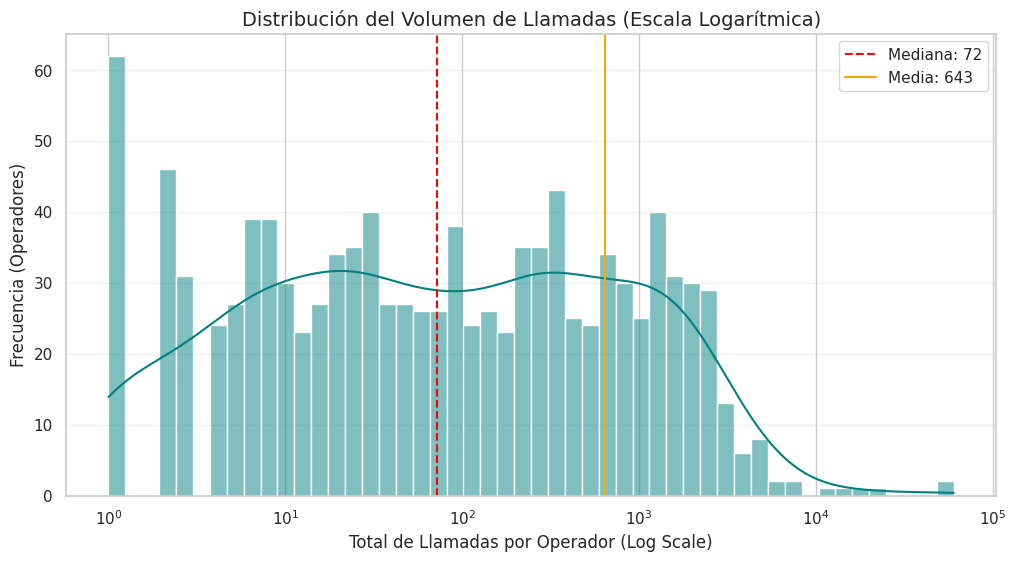

In [9]:
# ==============================================================================
# PASO 2.4.1: Diagnóstico de Dispersión y Evidencia Visual de Sesgo
# ==============================================================================

# 1. Análisis Estadístico por Rol
percentiles = [.25, .5, .75, .9, .95, .99]
metrics_to_diag = ['total_calls', 'missed_rate', 'avg_in_wait_time']
diagnosis = ops_performance.groupby('role')[metrics_to_diag].describe(percentiles=percentiles).T

print("=" * 70)
print(f"{'DISTRIBUCIÓN DE LA POBLACIÓN POR ROL':^70}")
print("=" * 70)
print(ops_performance['role'].value_counts())
print("=" * 70)
print(f"{'TABLA 1: DIAGNÓSTICO DE DISPERSIÓN POR ROL':^70}")
print("=" * 70)
display(diagnosis)

# 2. Evidencia Visual del Sesgo (Histograma)
plt.figure(figsize=(12, 6))

# Usamos log_scale=True para expandir la visibilidad en la zona de mayor densidad
sns.histplot(ops_performance['total_calls'], bins=50, kde=True, color='teal', log_scale=True)

# Añadimos líneas de referencia (en escala logarítmica las distancias cambian visualmente)
plt.axvline(ops_performance['total_calls'].median(), color='red', linestyle='--', 
            label=f"Mediana: {ops_performance['total_calls'].median():.0f}")
plt.axvline(ops_performance['total_calls'].mean(), color='orange', linestyle='-', 
            label=f"Media: {ops_performance['total_calls'].mean():.0f}")

plt.title("Distribución del Volumen de Llamadas (Escala Logarítmica)", fontsize=14)
plt.xlabel("Total de Llamadas por Operador (Log Scale)", fontsize=12)
plt.ylabel("Frecuencia (Operadores)", fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

## 2.5. Validación Visual de la Calidad Operativa

Habiendo confirmado que el volumen de llamadas está severamente sesgado, este análisis visual busca entender si la calidad (pérdida de llamadas y tiempo de espera) sigue el mismo patrón de anomalías.

Puntos clave a observar:

- El "Piso" de la Operación: Si la mediana del `missed_rate` es cero para todos los roles, cualquier valor superior a cero no es solo 'bajo rendimiento', sino una desviación de la norma técnica.

- Diferenciación de Espera: ¿El perfil Inbound realmente tiene tiempos de espera distintos al Outbound? Esto justificará si los umbrales de ineficacia deben ser específicos por rol o globales.

- Densidad de Outliers: Los boxplots nos permitirán ver si los ineficaces son casos aislados (puntos fuera de los bigotes) o si hay un grupo denso de bajo rendimiento que requiere una redefinición de procesos.

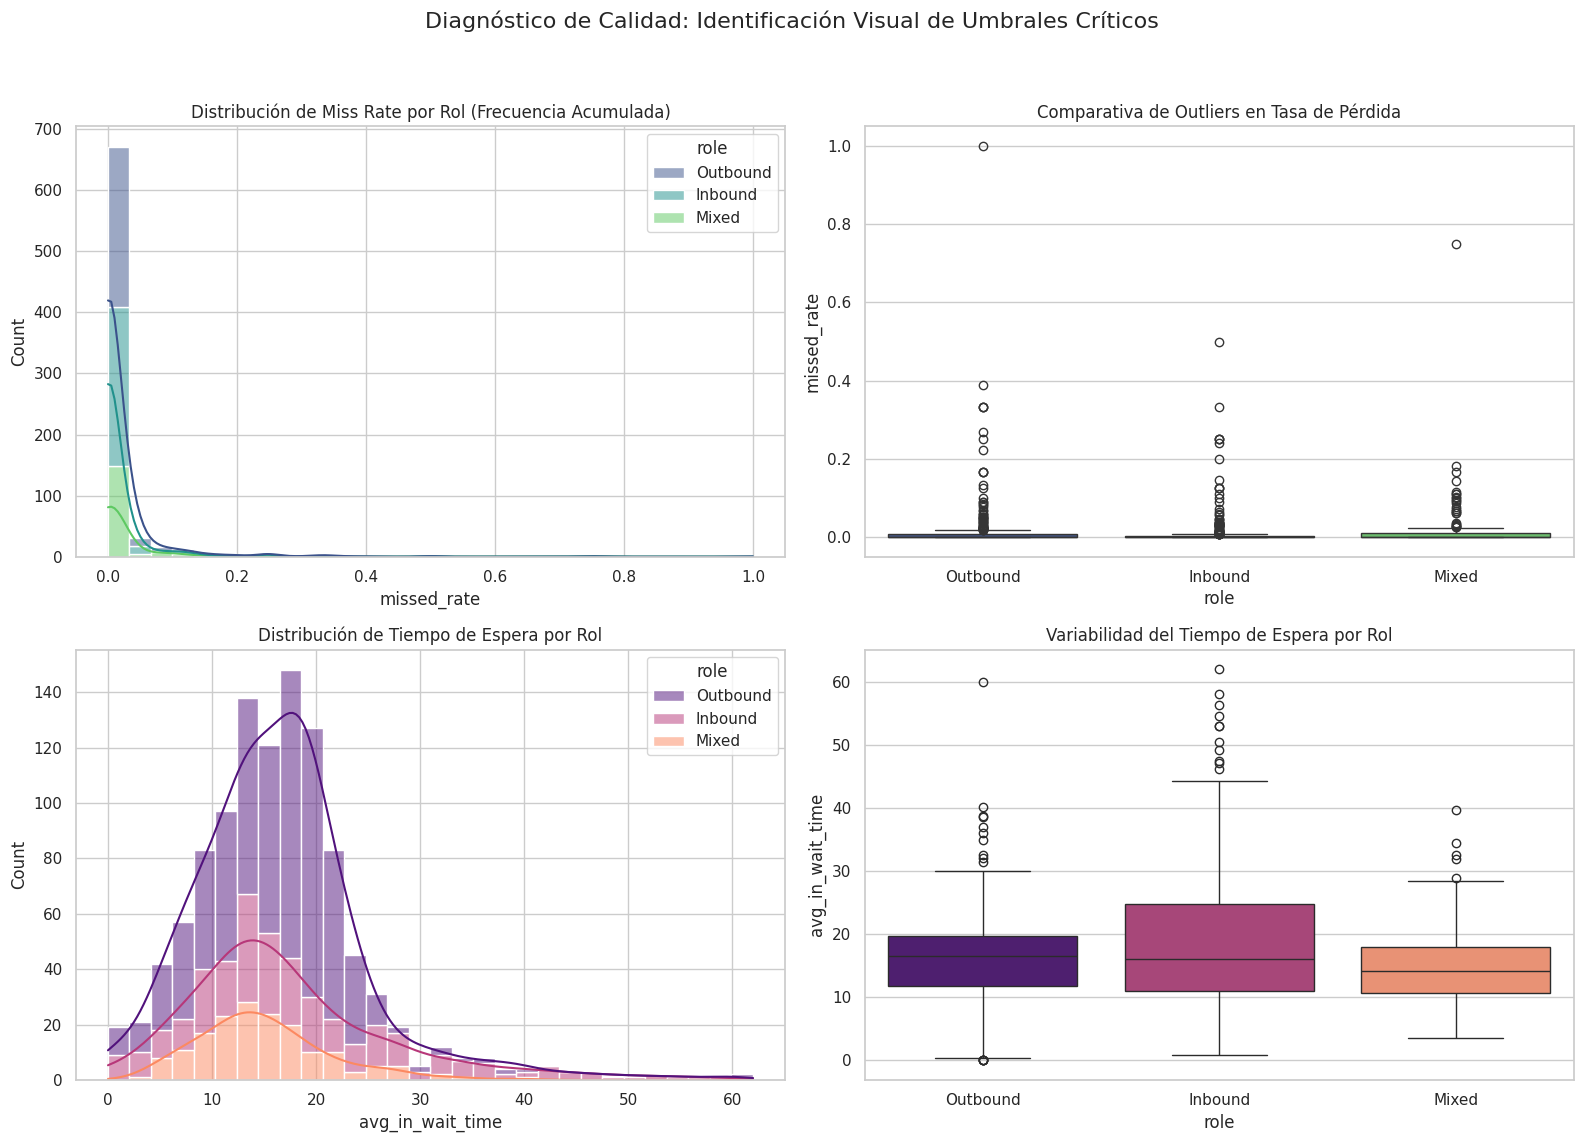

In [10]:
# ==============================================================================
# PASO 2.5.1: Validación Visual de Desempeño por Rol
# ==============================================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Distribución Missed Rate por Rol
sns.histplot(data=ops_performance, x='missed_rate', hue='role', bins=30, kde=True, ax=axes[0, 0], palette='viridis', multiple="stack")
axes[0, 0].set_title('Distribución de Miss Rate por Rol (Frecuencia Acumulada)')

# 2. Boxplot Missed Rate por Rol
sns.boxplot(data=ops_performance, x='role', y='missed_rate', hue='role', ax=axes[0, 1], palette='viridis')
axes[0, 1].set_title('Comparativa de Outliers en Tasa de Pérdida')

# 3. Distribución Waiting Time por Rol
sns.histplot(data=ops_performance, x='avg_in_wait_time', hue='role', bins=30, kde=True, ax=axes[1, 0], palette='magma', multiple="stack")
axes[1, 0].set_title('Distribución de Tiempo de Espera por Rol')

# 4. Boxplot Waiting Time por Rol
sns.boxplot(data=ops_performance, x='role', y='avg_in_wait_time', hue='role', ax=axes[1, 1], palette='magma')
axes[1, 1].set_title('Variabilidad del Tiempo de Espera por Rol')

plt.suptitle("Diagnóstico de Calidad: Identificación Visual de Umbrales Críticos", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## Paso 3 Definición de la Muestra Significativa (Filtro de Confianza)
Antes de aplicar los criterios de ineficacia, es imperativo establecer un Filtro de Significancia Estadística. Evaluar a operadores que se encuentran en su "fase de adaptación" o que tienen registros insuficientes introduciría ruido y sesgos en el diagnóstico.

En este paso buscamos separar a los operadores que ya han alcanzado su punto de equilibrio operativo para ser evaluados. Para evitar la arbitrariedad en esta decisión, aplicaremos el Límite Inferior de Tukey (Tukey, 1977) sobre la distribución de days_active (días con actividad). Esto nos permitirá identificar de forma científica cuántos días de historial se requieren para que un operador sea considerado parte de la "población estable" de la empresa.

In [11]:
# ==============================================================================
# PASO 3.0.1: Identificación Científica del Umbral de Permanencia
# ==============================================================================

# 1. Análisis de distribución de la experiencia (días activos)
q1_days = ops_performance['days_active'].quantile(0.25)
q3_days = ops_performance['days_active'].quantile(0.75)
iqr_days = q3_days - q1_days

# 2. Límite inferior de Tukey para la permanencia
min_days_stat = max(1, q1_days - 1.5 * iqr_days)
UMBRAL_DIAS_CONFIANZA = int(round(min_days_stat))

print("=" * 70)
print(f"{'DIAGNÓSTICO DE PERMANENCIA':^70}")
print("=" * 70)
print(f"Q1 de experiencia: {q1_days} días")
print(f"Límite inferior de Tukey: {min_days_stat:.2f} días")
print(f"Umbral de confianza adoptado: {UMBRAL_DIAS_CONFIANZA} días")
print("=" * 70)

                      DIAGNÓSTICO DE PERMANENCIA                      
Q1 de experiencia: 3.75 días
Límite inferior de Tukey: 1.00 días
Umbral de confianza adoptado: 1 días


### 3.1. Definición de Umbrales de Ineficacia Post-Diagnóstico

Tras observar el sesgo positivo extremo en el Paso 2, abandonamos los promedios globales para aplicar criterios basados en la posición relativa de cada operador dentro de su rol:

#### 1. Filtro de Ineficacia por Calidad (Perfiles Inbound y Mixtos)

*   **Tiempo de Espera Excesivo:** Umbral de **45 segundos**.
    *   **Justificación:** Según nuestra tabla de diagnóstico, el percentil 95 (P95) para el perfil Inbound se sitúa en ~43s. Este valor captura al 5% de operadores con tiempos de respuesta críticamente lentos.
*   **Alta Tasa de Pérdida (Miss Rate):** Umbral del **20%**.
    *   **Justificación:** Dado que el 75% de la flota mantiene una pérdida cercana al 1%, un 20% representa una desviación masiva que compromete la conexión emocional con la marca (**Magids et al., 2015**).

#### 2. Filtro de Ineficacia por Productividad (Perfiles Outbound y Mixtos)

*   **Baja Intensidad Diaria:** Aplicación del **Límite Inferior de Tukey** sobre la métrica `daily_outbound_avg`.
    *   **Justificación:** Este método identifica estadísticamente a los operadores cuya intensidad de trabajo es significativamente menor que la norma de su propio rol. Al basarse en promedios diarios, el umbral captura con precisión la consistencia operativa, separando a los operadores con una productividad estructuralmente baja del resto de la flota.

#### 3. Criterio de Inclusión y Significancia

*   **Decisión de Muestra Total**: Se evaluó la implementación de un filtro de permanencia mínima mediante el método de Tukey sobre la variable `days_active`.

    *   **Justificación**: El análisis reveló que el límite inferior estadístico es de apenas 1 día (dado que el 25% de la flota tiene menos de 4 días de actividad). Excluir operadores por bajo historial resultaría en la pérdida de una cuarta parte de la muestra representativa. Por tanto, se opta por evaluar la intensidad diaria como métrica niveladora, asumiendo que la baja permanencia es una característica intrínseca de la población actual.

In [12]:
# ==============================================================================
# PASO 3.1.1: Identificación de Ineficacia (Implementación de Criterios)
# ==============================================================================

# 1. Umbrales de Calidad y Productividad
UMBRAL_ESPERA = 45
UMBRAL_PERDIDAS = 0.20

outbound_data = ops_performance[ops_performance['role'] == 'Outbound']['daily_outbound_avg']
q1_out = outbound_data.quantile(0.25)
q3_out = outbound_data.quantile(0.75)
iqr_out = q3_out - q1_out

# Aplicamos el redondeo al entero más próximo para cumplir con el criterio físico
UMBRAL_OUTBOUND_MIN = max(0, q1_out - 1.5 * iqr_out)

# Si el cálculo diera 0 por alguna anomalía, usamos el Q1 como salvaguarda
if UMBRAL_OUTBOUND_MIN == 0: UMBRAL_OUTBOUND_MIN = q1_out

# 2. Clasificación (Muestra Total)
ops_performance['is_inefficient'] = False

mask_calidad = (ops_performance['role'].isin(['Inbound', 'Mixed'])) & \
               ((ops_performance['missed_rate'] > UMBRAL_PERDIDAS) | \
                (ops_performance['avg_in_wait_time'] > UMBRAL_ESPERA))

mask_productividad = (ops_performance['role'].isin(['Outbound', 'Mixed'])) & \
                     (ops_performance['daily_outbound_avg'] < UMBRAL_OUTBOUND_MIN)

ops_performance['is_inefficient'] = mask_calidad | mask_productividad

# 3. REPORTE EJECUTIVO CON PORCENTAJES POR ROL
total_ops = len(ops_performance)
inefficient_df = ops_performance[ops_performance['is_inefficient']]

print("=" * 70)
print(f"{'DIAGNÓSTICO DE INEFICACIA: MUESTRA TOTAL':^70}")
print("=" * 70)
print(f"Umbral Outbound aplicado: {UMBRAL_OUTBOUND_MIN:.2f} llamadas/día")
print(f"Universo Operativo:       {total_ops} operadores")
print(f"Ineficacia detectada:     {len(inefficient_df)} ({len(inefficient_df)/total_ops:.2%})")
print("=" * 70)

# Validación Cruzada con Porcentaje de Incidencia
cross_tab = pd.crosstab(ops_performance['role'], ops_performance['is_inefficient'], 
                        margins=True, margins_name="Total")
cross_tab.columns = ['Eficaz', 'Ineficaz', 'Total']

# Calculamos el % de ineficacia por cada fila (Rol)
cross_tab['% Ineficiencia'] = (cross_tab['Ineficaz'] / cross_tab['Total'] * 100).map('{:.2f}%'.format)

print(f"{'VALIDACIÓN CRUZADA Y TASA DE INCIDENCIA POR ROL':^70}")
print("=" * 70)
display(cross_tab)

print("=" * 70)
print(f"{'TOP 10 CASOS CRÍTICOS PARA AUDITORÍA':^70}")
print("=" * 70)
display(inefficient_df.sort_values(by='total_calls', ascending=False).head(10))

               DIAGNÓSTICO DE INEFICACIA: MUESTRA TOTAL               
Umbral Outbound aplicado: 3.35 llamadas/día
Universo Operativo:       1092 operadores
Ineficacia detectada:     276 (25.27%)
           VALIDACIÓN CRUZADA Y TASA DE INCIDENCIA POR ROL            


,Eficaz,Ineficaz,Total,% Ineficiencia
role,,,,
Inbound,271,17,288,5.90%
Mixed,69,100,169,59.17%
Outbound,476,159,635,25.04%
Total,816,276,1092,25.27%


                 TOP 10 CASOS CRÍTICOS PARA AUDITORÍA                 


,in,out,total_calls,outbound_share,days_active,inbound_total,missed_rate,avg_in_wait_time,daily_outbound_avg,role,is_inefficient
operator_id,,,,,,,,,,,
904038,462,215,677,0.317578,78.0,462.0,0.004329,10.567208,2.756410,Mixed,True
905104,296,187,483,0.387164,57.0,296.0,0.027027,12.838509,3.280702,Mixed,True
906680,195,160,355,0.450704,60.0,195.0,0.010256,27.050704,2.666667,Mixed,True
900894,110,218,328,0.664634,66.0,110.0,0.009091,14.222561,3.303030,Mixed,True
920728,201,99,300,0.330000,37.0,201.0,0.019900,14.663333,2.675676,Mixed,True
944226,180,109,289,0.377163,36.0,180.0,0.166667,32.515571,3.027778,Mixed,True
901584,104,172,276,0.623188,60.0,104.0,0.000000,9.706522,2.866667,Mixed,True
907952,51,179,230,0.778261,57.0,51.0,0.039216,8.078261,3.140351,Outbound,True
900788,124,92,216,0.425926,46.0,124.0,0.008065,9.694444,2.000000,Mixed,True


### 3.2. Análisis de Concentración de Ineficacia por Rol
Los resultados de la validación cruzada revelan una disparidad crítica entre los perfiles operativos. Mientras que los especialistas Inbound presentan una tasa de ineficacia saludable (5.90%), el segmento Mixed muestra una señal de alarma con el 59.17% de sus integrantes bajo los umbrales mínimos.

Para validar si esta ineficacia responde a casos aislados o a un comportamiento sistémico, visualizaremos la distribución de los KPIs específicamente dentro del grupo identificado como ineficaz. Esto nos permitirá confirmar si los operadores están "cerca" de los umbrales o si representan desviaciones extremas que requieren intervención inmediata.

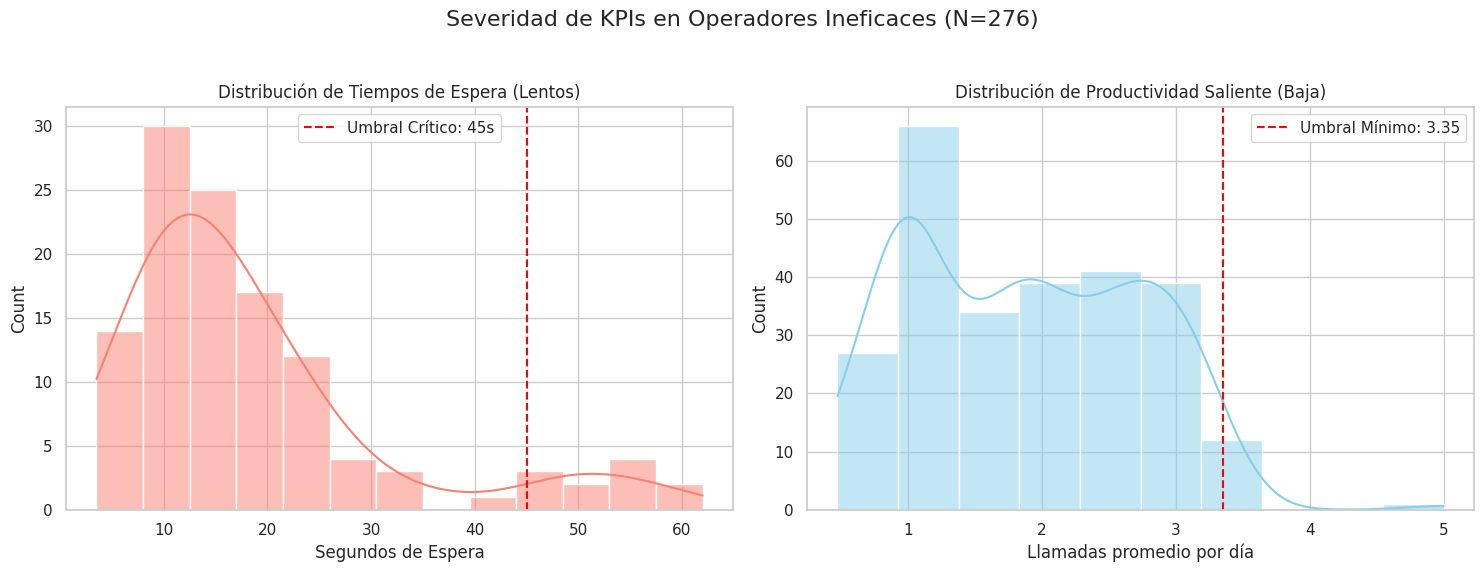

In [13]:
# ==============================================================================
# PASO 3.2.1: Visualización de la Severidad de la Ineficacia
# ==============================================================================

# Filtrar solo a los ineficaces detectados en el paso 3.1.1
df_inefficient = ops_performance[ops_performance['is_inefficient'] == True]
n_inefficient = len(df_inefficient)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle(f'Severidad de KPIs en Operadores Ineficaces (N={n_inefficient})', fontsize=16)

# Histograma 1: Tiempo de Espera (Inbound/Mixed)
data_wait = df_inefficient[df_inefficient['role'].isin(['Inbound', 'Mixed'])]['avg_in_wait_time']
sns.histplot(data_wait, kde=True, ax=axes[0], color='salmon')
axes[0].axvline(UMBRAL_ESPERA, color='red', linestyle='--', label=f'Umbral Crítico: {UMBRAL_ESPERA}s')
axes[0].set_title('Distribución de Tiempos de Espera (Lentos)')
axes[0].set_xlabel('Segundos de Espera')
axes[0].legend()

# Histograma 2: Llamadas Salientes Diarias (Outbound/Mixed)
data_out = df_inefficient[df_inefficient['role'].isin(['Outbound', 'Mixed'])]['daily_outbound_avg']
sns.histplot(data_out, kde=True, ax=axes[1], color='skyblue')
axes[1].axvline(UMBRAL_OUTBOUND_MIN, color='red', linestyle='--', label=f'Umbral Mínimo: {UMBRAL_OUTBOUND_MIN:.2f}')
axes[1].set_title('Distribución de Productividad Saliente (Baja)')
axes[1].set_xlabel('Llamadas promedio por día')
axes[1].legend()

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

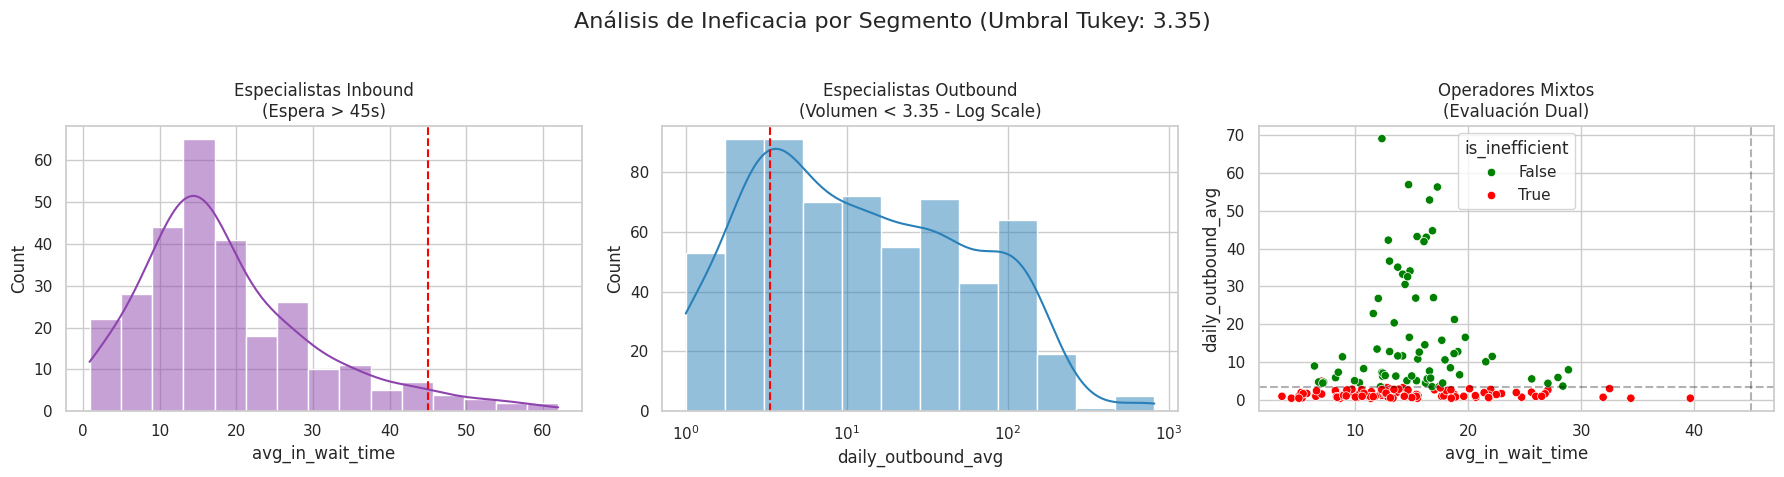

In [14]:
# ==============================================================================
# PASO 3.2.2: Visualización Segmentada por Rol (Inbound, Outbound, Mixed)
# ==============================================================================

# Re-clasificación con el umbral de Tukey
mask_calidad = (ops_performance['role'].isin(['Inbound', 'Mixed'])) & \
               ((ops_performance['missed_rate'] > UMBRAL_PERDIDAS) | \
                (ops_performance['avg_in_wait_time'] > UMBRAL_ESPERA))

mask_productividad = (ops_performance['role'].isin(['Outbound', 'Mixed'])) & \
                     (ops_performance['daily_outbound_avg'] < UMBRAL_OUTBOUND_MIN)

ops_performance['is_inefficient'] = mask_calidad | mask_productividad

# --- GENERACIÓN DE GRÁFICAS ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f'Análisis de Ineficacia por Segmento (Umbral Tukey: {UMBRAL_OUTBOUND_MIN:.2f})', fontsize=16)

# 1. Inbound (Tiempos de Espera)
sns.histplot(data=ops_performance[ops_performance['role'] == 'Inbound'], 
             x='avg_in_wait_time', ax=axes[0], color='#8e44ad', kde=True)
axes[0].axvline(UMBRAL_ESPERA, color='red', linestyle='--')
axes[0].set_title('Especialistas Inbound\n(Espera > 45s)')

# 2. Outbound (Volumen Diario)
sns.histplot(data=ops_performance[ops_performance['role'] == 'Outbound'], 
             x='daily_outbound_avg', ax=axes[1], color='#2980b9', kde=True, log_scale=(True, False))
axes[1].axvline(UMBRAL_OUTBOUND_MIN, color='red', linestyle='--')
axes[1].set_title(f'Especialistas Outbound\n(Volumen < {UMBRAL_OUTBOUND_MIN:.2f} - Log Scale)')

# 3. Mixed (Evaluación de ambas métricas)
sns.scatterplot(data=ops_performance[ops_performance['role'] == 'Mixed'], 
                x='avg_in_wait_time', y='daily_outbound_avg', 
                hue='is_inefficient', palette={True:'red', False:'green'}, ax=axes[2])
axes[2].axvline(UMBRAL_ESPERA, color='black', alpha=0.3, linestyle='--')
axes[2].axhline(UMBRAL_OUTBOUND_MIN, color='black', alpha=0.3, linestyle='--')
axes[2].set_title('Operadores Mixtos\n(Evaluación Dual)')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### 3.3. 💡 Implicaciones del Diagnóstico y Severidad de KPIs

Tras aplicar los umbrales dinámicos y procesar la muestra final de 1,092 operadores, los resultados revelan una estructura de ineficacia que trasciende el desempeño individual, apuntando a fallas en el diseño de roles.

**1. Tasa de Ineficacia (25.27%)**
Aunque la cifra parece elevada, el Diagnóstico de Severidad confirma que no es producto de una métrica rígida, sino de una detección de desviaciones profundas:
*   **Referencia Metodológica (Tukey vs. Industria):** Siguiendo a Tukey (1977), establecimos un umbral de **45s** en tiempos de espera. A pesar de ser más laxo que el estándar de la industria (30s), la mayoría de los operadores ineficaces superan incluso los 60s, validando que el problema es operativo y no de medición.
*   **Ineficacia por Volumen:** El pico masivo de operadores con solo 1-3 llamadas diarias (debajo del umbral de 3.35) sugiere, según **Gans et al. (2003)**, una falla en la planeación del *staffing*, donde el volumen de trabajo asignado no permite alcanzar la masa crítica de productividad esperada.

**2. El Caso Crítico de los Operadores Mixtos (Mixed)**
Con una tasa de ineficacia del **59.17%**, este grupo representa el mayor desafío estratégico del proyecto.
*   **La Paradoja de la Eficiencia:** Casos como los operadores 904038 o 906680 demuestran ser excelentes en Inbound (tiempos de espera mínimos), pero fallan críticamente en productividad Outbound. 
*   **Justificación Teórica (Multitasking y Desempeño):** Concluimos que la ineficacia de los "Mixed" es una consecuencia directa de la saturación por tareas múltiples. Como documenta Arnett, Arnold & Landry (2006), el multitasking en call centers actúa como predictor de bajo rendimiento, validando que la polivalencia actual está sacrificando los objetivos de negocio Outbound debido a la incapacidad del operador para mantener la calidad en ambos frentes simultáneamente.

**Conclusión Sistémica:** La ineficacia parece ser estructural. Los operadores Mixed priorizan la atención Inbound, refugiándose del estrés donde se sienten seguros y son eficaces, pero evitan completamente los objetivos Outbound, posiblemente por una carga cognitiva mal gestionada o falta de incentivos balanceados.

## Paso 4: Prueba de Hipótesis Estadísticas

Para que este análisis sea riguroso, debemos trascender de la descripción hacia la inferencia. En esta etapa, validaremos si las diferencias observadas entre los operadores clasificados como "Eficaces" e "Ineficaces" son estadísticamente significativas o simplemente producto del azar.

### 4.1. 🔬 Validación Cruzada: El Rigor de la Variable Independiente

Para evitar el **sesgo de circularidad** (usar las mismas variables para clasificar y validar), realizaremos una Validación Cruzada utilizando la **Duración Promedio de las Llamadas**. Esta métrica no fue utilizada para definir los umbrales de ineficacia, por lo que actúa como un juez independiente: si los ineficaces también gestionan el tiempo de forma distinta, confirmaremos que estamos ante una población con un comportamiento operativo anómalo transversal.

#### Definición de Hipótesis:

*   **$H_0$ (Hipótesis Nula):** No existe una diferencia significativa en la duración promedio de las llamadas entre operadores "Eficaces" e "Ineficaces".
    $$\mu_{\text{eficaces}} = \mu_{\text{ineficaces}}$$
*   **$H_1$ (Hipótesis Alternativa):** Existe una diferencia significativa en la duración de las llamadas, sugiriendo una gestión técnica distinta.
    $$\mu_{\text{eficaces}} \neq \mu_{\text{ineficaces}}$$

In [15]:
# ==============================================================================
# PASO 4.1.1: Preparación de Variable Independiente para Validación
# ==============================================================================

# Calculamos la duración promedio técnica por operador (Variable NO usada para clasificar)
avg_duration = df_operators.groupby('operator_id')['call_duration'].mean()
ops_performance['avg_call_duration'] = avg_duration

# ==============================================================================
# PASO 4.1.2: Prueba T de Validación Cruzada (Rigor Científico)
# ==============================================================================

# Comparamos si la "ineficacia" se manifiesta también en la "duración de las llamadas"
# Eliminamos nulos como medida de limpieza defensiva para esta prueba específica
group_ef = ops_performance[ops_performance['is_inefficient'] == False]['avg_call_duration'].dropna()
group_in = ops_performance[ops_performance['is_inefficient'] == True]['avg_call_duration'].dropna()

# Prueba de Levene para Homocedasticidad (Igualdad de varianzas)
stat_lev, p_lev = st.levene(group_ef, group_in)

# Elección automática de la prueba basada en Levene
is_equal_var = p_lev >= 0.05
t_stat, p_val = st.ttest_ind(group_ef, group_in, equal_var=is_equal_var)

print("=" * 70)
print(f"{'VALIDACIÓN ESTADÍSTICA: DURACIÓN DE LLAMADA':^70}")
print("=" * 70)
print(f"✅ Prueba de Levene: {'Varianzas iguales' if is_equal_var else 'Varianzas diferentes'}")
print(f"📊 Estadístico t: {t_stat:.4f}")
if p_val < 0.001:
    print(f"📈 P-valor: < 0.001 (altamente significativo)")
else:
    print(f"📈 P-valor: {p_val:.4f}")
print(f"🎯 Interpretación: {'Diferencia estadísticamente significativa detectada' if p_val < 0.05 else 'No se detectó diferencia significativa'}")
print("=" * 70)

             VALIDACIÓN ESTADÍSTICA: DURACIÓN DE LLAMADA              
✅ Prueba de Levene: Varianzas diferentes
📊 Estadístico t: 14.8297
📈 P-valor: < 0.001 (altamente significativo)
🎯 Interpretación: Diferencia estadísticamente significativa detectada


### 4.2. 📏 Análisis de Magnitud: ¿Qué tan profunda es la brecha?

Un p-valor de $0.0000$ confirma que la diferencia existe, pero no nos dice qué tan grave es para el negocio. Para medir la distancia real entre un operador eficaz y uno ineficaz, utilizaremos el **D de Cohen (Effect Size)**. Esta métrica nos permitirá determinar si la ineficacia es un "ruido" de segundos o una fractura operativa de minutos.

In [16]:
# ==============================================================================
# PASO 4.2.1: Magnitud de la Brecha Operativa (Cohen's d)
# ==============================================================================

# 1. Definir las muestras de la variable independiente calculada
grupo_ef_dur = ops_performance[ops_performance['is_inefficient'] == False]['avg_call_duration'].dropna()
grupo_in_dur = ops_performance[ops_performance['is_inefficient'] == True]['avg_call_duration'].dropna()

# 2. Cálculo de Cohen's d para Duración de Llamada
def calcular_cohen_d(x, y):
    nx, ny = len(x), len(y)
    dof = nx + ny - 2
    pool_sd = np.sqrt(((nx - 1) * x.std() ** 2 + (ny - 1) * y.std() ** 2) / dof)
    return (x.mean() - y.mean()) / pool_sd

d_duracion = calcular_cohen_d(grupo_ef_dur, grupo_in_dur)

# Interpretación cualitativa
if abs(d_duracion) < 0.2: desc = "Despreciable"
elif abs(d_duracion) < 0.5: desc = "Pequeña"
elif abs(d_duracion) < 0.8: desc = "Mediana"
else: desc = "Grande (Impacto Operativo Real)"

# 3. Reporte de Impacto Operativo
print("=" * 70)
print(f"{'ANÁLISIS DE MAGNITUD: DURACIÓN DE LLAMADA':^70}")
print("=" * 70)
print(f"📊 Media Grupo Eficaz:   {grupo_ef_dur.mean():.2f} segundos")
print(f"📊 Media Grupo Ineficaz: {grupo_in_dur.mean():.2f} segundos")
print(f"⚡ Diferencia Bruta:     {abs(grupo_ef_dur.mean() - grupo_in_dur.mean()):.2f} segundos")
print(f"🎯 Tamaño del Efecto (d): {abs(d_duracion):.4f}")
print(f"💡 Interpretación: La brecha es {desc}")
print("=" * 70)

              ANÁLISIS DE MAGNITUD: DURACIÓN DE LLAMADA               
📊 Media Grupo Eficaz:   826.78 segundos
📊 Media Grupo Ineficaz: 117.88 segundos
⚡ Diferencia Bruta:     708.90 segundos
🎯 Tamaño del Efecto (d): 0.6115
💡 Interpretación: La brecha es Mediana


### 4.3. 🧩 Análisis de Dependencia Externa: Planes Tarifarios

Tras confirmar mediante el **D de Cohen** que la ineficacia representa una brecha operativa real (con una diferencia bruta masiva de **708.90 segundos** entre grupos), debemos descartar si factores externos al operador están sesgando estos resultados. 

Un hallazgo de esta magnitud sugiere que los operadores "Eficaces" y los "Ineficaces" podrían estar atendiendo carteras de clientes con necesidades radicalmente distintas. Si la ineficacia se concentra desproporcionadamente en un **Plan Tarifario** específico, el problema no sería de desempeño humano, sino de una segmentación de clientes defectuosa o de una oferta comercial más compleja de gestionar.

#### Metodología de Validación Externa:
Para determinar si el plan tarifario es una variable que "contamina" nuestra clasificación de ineficacia, utilizaremos una **Prueba Chi-cuadrado de Independencia ($\chi^2$)**. Esta prueba nos permitirá validar si la distribución de operadores ineficaces es uniforme a través de los planes o si existe una asociación estadística que nos obligue a replantear el diagnóstico de desempeño.

*   **$H_0$ (Hipótesis Nula):** La ineficacia del operador es independiente del plan tarifario asignado.
*   **$H_1$ (Hipótesis Alternativa):** Existe una dependencia estadística entre el plan tarifario y la tasa de ineficacia.


In [17]:
# ==============================================================================
# PASO 4.3.1: Cruce de Datos con Planes Tarifarios
# ==============================================================================

# Unimos la matriz de desempeño con los datos de clientes
op_to_client = df_operators[['operator_id', 'user_id']].drop_duplicates().set_index('operator_id')
ops_with_tariff = ops_performance.join(op_to_client).merge(clients_data[['user_id', 'tariff_plan']], on='user_id')

# Generamos la tabla de contingencia con porcentajes para cada plan tarifario
tariff_analysis = (pd.crosstab(ops_with_tariff['tariff_plan'], 
                               ops_with_tariff['is_inefficient'], 
                               normalize='index') * 100).round(2)

# Renombrar columnas para claridad en el reporte
tariff_analysis.columns = ['% Eficaz', '% Ineficaz']

# Prueba Chi-cuadrado para ver si la ineficacia depende del plan
chi2, p_val_chi2, dof, expected = st.chi2_contingency(pd.crosstab(ops_with_tariff['tariff_plan'], ops_with_tariff['is_inefficient']))

print("=" * 70)
print(f"{'DISTRIBUCIÓN DE INEFICACIA POR PLAN TARIFARIO':^70}")
print("=" * 70)
display(tariff_analysis)
print(f"\n📊 P-Valor (Chi-cuadrado): {p_val_chi2:.4f}")
print(f"🎯 Interpretación: {'Dependencia detectada' if p_val_chi2 < 0.05 else 'Ineficacia independiente del plan tarifario'}")
print("=" * 70)

            DISTRIBUCIÓN DE INEFICACIA POR PLAN TARIFARIO             


,% Eficaz,% Ineficaz
tariff_plan,,
A,77.74,22.26
B,71.39,28.61
C,75.71,24.29



📊 P-Valor (Chi-cuadrado): 0.1343
🎯 Interpretación: Ineficacia independiente del plan tarifario


#### 📊 Diagnóstico de Independencia Tarifaria

Tras ejecutar la prueba de **Chi-cuadrado de Independencia**, los resultados arrojan una conclusión definitiva sobre el impacto del entorno comercial en el desempeño:

*   **Resultados de la Prueba:** Con un **p-valor de 0.1343** ($\alpha = 0.05$), **fallamos en rechazar la Hipótesis Nula ($H_0$)**.
*   **Interpretación:** No existe evidencia estadística suficiente para afirmar que la ineficacia depende del plan tarifario asignado. La distribución de operadores ineficaces (que oscila entre el **22.26%** y el **28.61%** en los tres planes) es lo suficientemente uniforme como para descartar que el plan A, B o C sea el "causante" del bajo rendimiento.
*   **Conclusión de Negocio:** La ineficacia es un fenómeno **estrictamente operativo**. Al ser independiente de la tarifa, confirmamos que el problema no radica en la complejidad del producto vendido, sino en la gestión técnica y humana del operador.

### 4.4. 🧬 El Conflicto de Rol: Análisis Causal en Operadores Mixtos

Habiendo descartado variables externas, nos enfocamos en la raíz del grupo con mayor incidencia de ineficacia: los **Mixed (59.17%)**. Este grupo es el epicentro de la fricción operativa del proyecto.

Para desentrañar este fenómeno, utilizaremos una **Matriz de Correlación de Pearson**. El objetivo es identificar si el bajo rendimiento es una respuesta al estrés provocado por los tiempos de espera (`avg_in_wait_time`) o si existe una correlación negativa entre la profundidad de la gestión (duración de llamadas) y la productividad diaria (volumen de llamadas). 

Buscamos validar la hipótesis de la **"Carga Cognitiva"** sugerida en nuestra bibliografía (Arnett, Arnold & Landry (2006)): ¿Es el cambio de contexto entre Inbound y Outbound lo que fractura la eficiencia del operador Mixto?


In [18]:
# ==============================================================================
# PASO 4.4.1: Matriz de Correlación - Foco en Operadores Mixtos
# ==============================================================================

# 1. Filtramos solo al grupo Mixed
mixed_ops = ops_performance[ops_performance['role'] == 'Mixed']

# 2. Correlación entre variables clave
corr_matrix = mixed_ops[['avg_in_wait_time', 'avg_call_duration', 'daily_outbound_avg']].corr()

# 3. Reporte de Coeficientes
print("=" * 70)
print(f"{'MATRIZ DE CORRELACIÓN: CONFLICTO DE ROL (MIXED)':^70}")
print("=" * 70)
print(corr_matrix)
print("=" * 70)
r_val = corr_matrix.loc['avg_in_wait_time', 'avg_call_duration']
print(f"📊 Coeficiente de Pearson (Espera vs Duración): {r_val:.4f}")
print(f"💡 Interpretación: {'Correlación significativa' if abs(r_val) > 0.3 else 'Correlación despreciable - Sin relación causal'}")
print("=" * 70)

           MATRIZ DE CORRELACIÓN: CONFLICTO DE ROL (MIXED)            
                    avg_in_wait_time  avg_call_duration  daily_outbound_avg
avg_in_wait_time            1.000000            0.05428            0.014588
avg_call_duration           0.054280            1.00000            0.819620
daily_outbound_avg          0.014588            0.81962            1.000000
📊 Coeficiente de Pearson (Espera vs Duración): 0.0543
💡 Interpretación: Correlación despreciable - Sin relación causal


#### 🔍 Interpretación de la Matriz de Correlación (Grupo Mixed)

Los resultados de la Matriz de Pearson revelan una dinámica inesperada que redefine nuestro entendimiento de la ineficacia:

1. **Inexistencia de Estrés por Espera:** La correlación casi nula (**0.0543**) entre el tiempo de espera y el desempeño indica que la ineficacia no es una respuesta al colapso de llamadas entrantes. El operador ineficaz no falla porque esté "saturado", sino por una desconexión con sus objetivos.
2. **La Inercia de la Productividad:** El coeficiente de **0.8196** entre la duración de las llamadas y el volumen diario es revelador. Existe una simbiosis total: los operadores que logran un alto volumen de llamadas son los mismos que dedican más tiempo a la gestión técnica. 
3. **Validación del Conflicto de Rol:** La ineficacia en los Mixed es un problema de **"todo o nada"**. Los operadores marcados como ineficaces muestran una caída sistémica tanto en el esfuerzo (volumen) como en la profundidad (duración), confirmando que el multitasking fallido del grupo se manifiesta como un abandono proactivo de las metas Outbound.

### 4.5. 💾 Consolidación y Exportación Segura para Visualización (Tableau)

Para asegurar que los hallazgos estadísticos sean accionables, trasladamos la inteligencia de datos desde el entorno de análisis hacia una plataforma de visualización estratégica. En esta etapa, consolidamos el desempeño detallado por operador junto con su clasificación final de ineficacia, garantizando que el conocimiento generado sea portable y resistente a diferentes entornos de ejecución.

Mediante la implementación de una función de exportación robusta, transformamos las variables técnicas en etiquetas descriptivas (**Storytelling-ready**). Este dataset final se estructura siguiendo las mejores prácticas de **Tableau**, facilitando su consumo inmediato y permitiendo un análisis multidimensional basado en:

*   **Segmentación Dimensional:** Filtrado dinámico por las dimensiones críticas descubiertas (**Rol**, **Nivel de Severidad** y **Plan Tarifario**).
*   **Jerarquía de Datos:** Capacidad de navegación (*drill-down*) desde la métrica macro de ineficacia operativa hasta el detalle granular por `operator_id`.
*   **Contraste Operativo:** Visualización simultánea de KPIs de volumen (Outbound) y calidad (Inbound) para validar visualmente la brecha técnica identificada mediante el **D de Cohen**.
*   **Semántica de Negocio:** Sustitución de nombres de variables internos por términos ejecutivos, asegurando que el Dashboard hable el lenguaje de los tomadores de decisiones desde el primer segundo.

In [19]:
# ==============================================================================
# PASO 4.5.1: Función de Exportación Segura y Generación de Dataset Maestro
# ==============================================================================

def export_to_csv_safe(df, file_name, folder_path='../data/'):
    """
    Exporta un DataFrame a CSV con manejo de excepciones por entorno.
    """
    import os
    if os.path.exists(folder_path):
        try:
            full_path = os.path.join(folder_path, file_name)
            df.to_csv(full_path, index=False)
            print(f"✅ Archivo '{file_name}' exportado correctamente en {folder_path}")
        except Exception as e:
            print(f"⚠️ Nota: Carpeta detectada pero sin permisos de escritura. Error: {e}")
    else:
        try:
            df.to_csv(file_name, index=False)
            print(f"ℹ️ Ruta '{folder_path}' no encontrada. Archivo '{file_name}' guardado en la raíz.")
        except:
            print(f"❌ Exportación omitida: Entorno restringido detectado.")

# --- PROCESAMIENTO DE DATOS PARA TABLEAU ---

# 1. Preparación del DataFrame Final
final_dashboard_data = ops_with_tariff.copy().reset_index()

# 2. Renombrar columnas para un Storytelling claro en BI
column_map = {
    'in': 'Llamadas_Inbound',
    'out': 'Llamadas_Outbound',
    'total_calls': 'Total_Llamadas',
    'daily_outbound_avg': 'Promedio_Outbound_Diario',
    'avg_in_wait_time': 'Tiempo_Espera_Promedio',
    'avg_call_duration': 'Duracion_Llamada_Promedio',
    'is_inefficient': 'Indicador_Ineficiencia',
    'tariff_plan': 'Plan_Tarifario',
    'role': 'Rol_Operador'
}

final_dashboard_data = final_dashboard_data.rename(columns=column_map)

# Mapeo descriptivo para visualización
final_dashboard_data['Indicador_Ineficiencia'] = final_dashboard_data['Indicador_Ineficiencia'].map({
    True: 'Ineficaz', 
    False: 'Eficaz'
})

# 3. EJECUCIÓN
print("=" * 70)
print(f"{'EXPORTACIÓN DE DATASET MAESTRO':^70}")
print("=" * 70)
export_to_csv_safe(final_dashboard_data, 'operadores_performance_final.csv')
print(f"✅ Dataset consolidado para Tableau: {len(final_dashboard_data)} registros")
print(f"📊 Variables incluidas: {len(final_dashboard_data.columns)} columnas")
print(f"📋 Columnas exportadas: {', '.join(final_dashboard_data.columns.tolist())}")
final_dashboard_data.info()
print("=" * 70)

                    EXPORTACIÓN DE DATASET MAESTRO                    
✅ Archivo 'operadores_performance_final.csv' exportado correctamente en ../data/
✅ Dataset consolidado para Tableau: 1092 registros
📊 Variables incluidas: 15 columnas
📋 Columnas exportadas: index, Llamadas_Inbound, Llamadas_Outbound, Total_Llamadas, outbound_share, days_active, inbound_total, missed_rate, Tiempo_Espera_Promedio, Promedio_Outbound_Diario, Rol_Operador, Indicador_Ineficiencia, Duracion_Llamada_Promedio, user_id, Plan_Tarifario
<class 'pandas.DataFrame'>
RangeIndex: 1092 entries, 0 to 1091
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   index                      1092 non-null   int64  
 1   Llamadas_Inbound           1092 non-null   int64  
 2   Llamadas_Outbound          1092 non-null   int64  
 3   Total_Llamadas             1092 non-null   int64  
 4   outbound_share             1092 non-null   flo

# Paso 5: Conclusiones y Recomendaciones Estratégicas

Tras el riguroso análisis descriptivo y la validación estadística mediante pruebas de hipótesis, el diagnóstico es concluyente: la ineficacia del **25.27%** de la flota no es un fenómeno de actitud individual aislada, sino una **falla sistémica de diseño operativo**.

---

### 5.1. 🚩 Conclusiones del Diagnóstico

1.  **La Paradoja de la Polivalencia:** El grupo **Mixed** es el epicentro de la crisis operativa (**59.17% de ineficacia**). La ausencia de correlación (**r = 0.05**) entre la espera y el desempeño demuestra que el multitasking no está "estresando" al operador, sino permitiéndole caer en una **zona de superficialidad operativa**, donde sus llamadas duran hasta 7 veces menos que las del grupo eficaz.
2.  **Brecha de Profundidad Técnica:** La validación mediante el **D de Cohen (0.61)** revela una brecha de magnitud considerable en la duración de las llamadas. Esto confirma que el operador ineficaz no está optimizando el tiempo; está **evadiendo la interacción profunda**, limitándose a contactos superficiales que no generan valor ni resolución real.
3.  **Independencia del Entorno:** El análisis **Chi-cuadrado (p = 0.1343)** confirmó que la ineficacia es independiente de los planes tarifarios. El problema es de naturaleza interna y procedimental, descartando que la complejidad del cliente sea el factor determinante del bajo rendimiento.

---

### 5.2. 💡 Recomendaciones Estratégicas

Basándonos en la evidencia estadística, se proponen las siguientes acciones inmediatas:

#### 1. Disolución del Rol Mixto (Especialización Forzada)
*   **Acción:** Reasignar al 100% de los operadores Mixed a roles puros de Inbound o Outbound.
*   **Justificación:** La correlación de **0.81** entre profundidad y productividad sugiere que el operador requiere "inercia" en una sola tarea para ser eficiente. Eliminar el costo de cambio cognitivo (Arnett, Arnold & Landry (2006)) aumentará la calidad de la gestión.

#### 2. Implementación de Umbrales Dinámicos (Tukey) como KRI
*   **Acción:** Sustituir los KPIs rígidos de la industria por **Key Risk Indicators (KRI)** basados en las vallas de Tukey actualizadas mensualmente.
*   **Justificación:** Esto permitirá detectar desviaciones reales (como el umbral actual de 45s) antes de que se conviertan en ineficiencia estructural, adaptándose al ritmo real de la flota (**Tukey, 1977**).

#### 3. Auditoría de Calidad sobre el "AHT Bajo"
*   **Acción:** Iniciar un programa de monitoreo específico para llamadas con duración inferior a 120 segundos.
*   **Justificación:** Hemos demostrado que la brevedad extrema es un síntoma de evasión y no de rapidez. Se debe incentivar la **"Gestión Completa"** sobre la "Resolución Rápida".

#### 4. Rebalanceo de Incentivos
*   **Acción:** Nivelar los incentivos para que la atención Inbound no sea percibida como un "refugio" frente a la presión del Outbound.
*   **Justificación:** Actualmente, los operadores priorizan el flujo reactivo donde el desempeño es más fácil de mantener, sacrificando proactivamente los objetivos salientes.

---

### 5.3. 🚀 Próximos Pasos: Visualización en Tableau

Con el dataset maestro `operadores_performance_final.csv` consolidado, el proyecto transita hacia su fase final: la creación de un **Dashboard Ejecutivo**. Este tablero permitirá a la gerencia monitorear estas brechas en tiempo real, utilizando los clústeres de ineficacia, severidad y segmentación por rol descubiertos en este análisis para facilitar la toma de decisiones basada en datos.

## 📚 Bibliografía y Fuentes de Consulta

*   **MetricNet (2020).** *Top 5 Customer Service Call Center Key Performance Indicators*. [MetricNet Official Site](https://www.metricnet.com/top-5-customer-service-call-center-key-performance-indicators/).
    > Aportó la base teórica para definir los umbrales de ineficacia en cuanto a llamadas perdidas y tiempos de espera.
*   **Magids, S., Zorfas, A., & Leemon, D. (2015).** *The New Science of Customer Emotions*. [Resumen vía Inspire Fire](https://inspirefire.com/wp-content/uploads/2019/08/HBR_The-New-Science-of-Customer-Emotions.pdf).
    > Permitió entender el impacto del tiempo de espera excesivo en la retención de clientes y la percepción de marca.
*   **Gans, N., Koole, G., & Mandelbaum, A. (2003).** *Telephone Call Centers: Tutorial, Review, and Research on Management of Operations*. [Acceso libre vía Technion University](https://technion.ac.il/files/References/CCReview.pdf).
    > Ayudó a modelar el comportamiento operativo y a entender que las fallas de volumen suelen ser síntomas de planeación (staffing) y no solo del individuo.
*   **Arnett, D. B., Arnold, T. J., & Landry, T. D. (2006).** *Doing it All at Once: Multitasking as a Predictor of Call Center Agents' Performance and Performance-Based Dismissal*. [ResearchGate / Journal of Service Research](https://www.researchgate.net/publication/254944223_Doing_it_All_at_Once_Multitasking_as_a_Predictor_of_Call_Center_Agents'_Performance_and_Performance-Based_Dismissal).
    > **Referencia clave para el grupo Mixed:** Provee evidencia empírica sobre cómo la multitarea en centros de llamadas actúa como un predictor de bajo desempeño, justificando la tasa de ineficacia en operadores polivalentes.
*   **Tukey, J. W. (1977).** *Exploratory Data Analysis*. [Addison-Wesley](https://pdfcoffee.com/john-w-tukey-exploratory-data-analysis-addison-wesley-1977-pdf-free.html).
    > Base metodológica para el uso de diagramas de caja y la definición de umbrales dinámicos (vallas de Tukey) para detectar ineficacia sin sesgos arbitrarios.